In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

disease_cols=["Cardiomegaly","Edema","Pleural Effusion"]

print("Device:",device)
print("Diseases:",disease_cols)

Device: cuda
Diseases: ['Cardiomegaly', 'Edema', 'Pleural Effusion']


In [2]:
class CNNClassifier(nn.Module):
    def __init__(self,num_classes,dropout=0.0):
        super().__init__()
        self.backbone=models.densenet121(weights="DEFAULT").features
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.dropout=nn.Dropout(dropout)
        self.classifier=nn.Linear(1024,num_classes)

    def forward(self,x):
        feat=F.relu(self.backbone(x))
        feat=self.pool(feat).flatten(1)
        return self.classifier(self.dropout(feat))

model_cnn=CNNClassifier(num_classes=len(disease_cols),dropout=0.0).to(device)

print(model_cnn)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 172MB/s]


CNNClassifier(
  (backbone): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        

In [3]:
import os

model_dir="/kaggle/input/models/suryasampreethchirla/6k-models/pytorch/default/1"

print(os.listdir(model_dir))

['best_chexgcn.pth', 'best_hybrid.pth', 'best_cnn.pth', 'best_cnn_matched.pth']


In [4]:
model_cnn=CNNClassifier(num_classes=3,dropout=0.0).to(device)

model_cnn.load_state_dict(
    torch.load(
        os.path.join(model_dir,"best_cnn.pth"),
        map_location=device
    )
)

model_cnn.eval()

print("CNN model loaded successfully")

CNN model loaded successfully


In [5]:
print("Classifier output shape:",model_cnn.classifier.out_features)
print("Disease order:",disease_cols)

Classifier output shape: 3
Disease order: ['Cardiomegaly', 'Edema', 'Pleural Effusion']


In [6]:
!pip install grad-cam -q

from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [7]:
target_layer=model_cnn.backbone.denseblock4
print(target_layer)

_DenseBlock(
  (denselayer1): _DenseLayer(
    (norm1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv1): Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (denselayer2): _DenseLayer(
    (norm1): BatchNorm2d(544, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv1): Conv2d(544, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (denselayer3): _DenseLayer(
    (norm1): BatchNorm2d(576, eps=1e-05, moment

In [8]:
dummy_input=torch.randn(1,3,224,224).to(device)

with torch.no_grad():
    output=model_cnn(dummy_input)

print("Output shape:",output.shape)
print("Output:",output)

Output shape: torch.Size([1, 3])
Output: tensor([[-0.4579, -0.6964,  0.7077]], device='cuda:0')


In [19]:
import os

for root,dirs,files in os.walk("/kaggle/input"):
    image_files=[f for f in files if f.lower().endswith((".jpg",".jpeg",".png"))]
    if image_files:
        print(root)
        print(image_files[:5])

/kaggle/input/datasets/ashery/chexpert/valid/patient64611/study1
['view1_frontal.jpg']
/kaggle/input/datasets/ashery/chexpert/valid/patient64545/study1
['view1_frontal.jpg']
/kaggle/input/datasets/ashery/chexpert/valid/patient64711/study1
['view1_frontal.jpg']
/kaggle/input/datasets/ashery/chexpert/valid/patient64612/study1
['view1_frontal.jpg']
/kaggle/input/datasets/ashery/chexpert/valid/patient64684/study1
['view1_frontal.jpg']
/kaggle/input/datasets/ashery/chexpert/valid/patient64648/study1
['view1_frontal.jpg']
/kaggle/input/datasets/ashery/chexpert/valid/patient64682/study1
['view1_frontal.jpg']
/kaggle/input/datasets/ashery/chexpert/valid/patient64587/study1
['view1_frontal.jpg']
/kaggle/input/datasets/ashery/chexpert/valid/patient64558/study1
['view2_lateral.jpg', 'view1_frontal.jpg']
/kaggle/input/datasets/ashery/chexpert/valid/patient64717/study1
['view1_frontal.jpg']
/kaggle/input/datasets/ashery/chexpert/valid/patient64542/study1
['view2_lateral.jpg', 'view1_frontal.jpg']
/

KeyboardInterrupt: 

In [9]:
image_path=image_path="/kaggle/input/datasets/ashery/chexpert/valid/patient64611/study1/view1_frontal.jpg"

print(image_path)

/kaggle/input/datasets/ashery/chexpert/valid/patient64611/study1/view1_frontal.jpg


In [10]:
from PIL import Image

image=Image.open(image_path).convert("RGB")

print("Image size:",image.size)

Image size: (389, 320)


In [11]:
import torchvision.transforms as transforms

transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

input_tensor=transform(image).unsqueeze(0).to(device)

print("Input shape:",input_tensor.shape)

Input shape: torch.Size([1, 3, 224, 224])


In [12]:
with torch.no_grad():
    logits=model_cnn(input_tensor)
    probabilities=torch.sigmoid(logits)

for i,disease in enumerate(disease_cols):
    print(f"{disease}: logit={logits[0,i].item():.4f}, probability={probabilities[0,i].item():.4f}")

Cardiomegaly: logit=-0.9900, probability=0.2709
Edema: logit=0.5673, probability=0.6381
Pleural Effusion: logit=0.6593, probability=0.6591


100%|██████████| 64/64 [00:03<00:00, 19.24it/s]


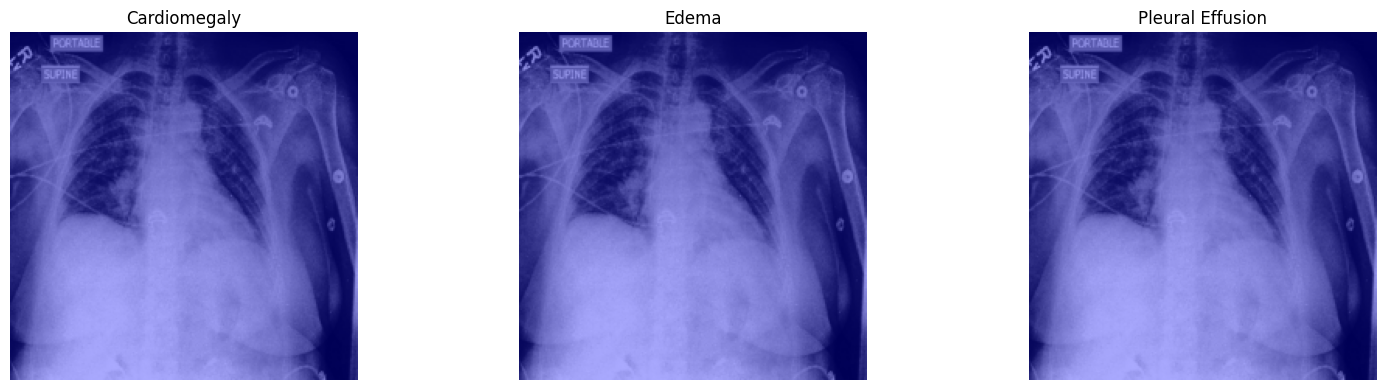

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model_cnn.eval()

target_layer=model_cnn.backbone.denseblock4
cam=ScoreCAM(model=model_cnn,target_layers=[target_layer])

rgb_image=np.array(TF.resize(image,(224,224))).astype(np.float32)/255.0

plt.figure(figsize=(16,4))

for i,disease in enumerate(disease_cols):
    grayscale_cam=cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(i)]
    )[0]

    cam_image=show_cam_on_image(rgb_image,grayscale_cam,use_rgb=True)

    plt.subplot(1,3,i+1)
    plt.imshow(cam_image)
    plt.title(disease)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
cams=[]

for i,disease in enumerate(disease_cols):
    grayscale_cam=cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(i)]
    )[0]
    cams.append(grayscale_cam)

for i in range(3):
    for j in range(i+1,3):
        diff=np.abs(cams[i]-cams[j])
        print(
            f"{disease_cols[i]} vs {disease_cols[j]}: "
            f"mean diff={diff.mean():.8f}, "
            f"max diff={diff.max():.8f}"
        )

100%|██████████| 64/64 [00:03<00:00, 19.14it/s]

Cardiomegaly vs Edema: mean diff=0.00000000, max diff=0.00000000
Cardiomegaly vs Pleural Effusion: mean diff=0.00000000, max diff=0.00000000
Edema vs Pleural Effusion: mean diff=0.00000000, max diff=0.00000000


In [15]:
weights=model_cnn.classifier.weight.detach().cpu()

print("Weight shape:",weights.shape)

for i,disease in enumerate(disease_cols):
    print(disease,weights[i,:5])

print("\nPairwise weight differences:")

for i in range(3):
    for j in range(i+1,3):
        diff=torch.abs(weights[i]-weights[j])
        print(
            f"{disease_cols[i]} vs {disease_cols[j]}: "
            f"mean={diff.mean().item():.8f}, "
            f"max={diff.max().item():.8f}"
        )

Weight shape: torch.Size([3, 1024])
Cardiomegaly tensor([-0.0049, -0.0140,  0.0085, -0.0144,  0.0121])
Edema tensor([-0.0107,  0.0009, -0.0268, -0.0056, -0.0257])
Pleural Effusion tensor([ 0.0165, -0.0022, -0.0098, -0.0150, -0.0145])

Pairwise weight differences:
Cardiomegaly vs Edema: mean=0.02066096, max=0.06055067
Cardiomegaly vs Pleural Effusion: mean=0.02030504, max=0.06306385
Edema vs Pleural Effusion: mean=0.02042900, max=0.06108622


In [16]:
import inspect

print(inspect.getsource(ScoreCAM.get_cam_weights))

    def get_cam_weights(self,
                        input_tensor,
                        target_layer,
                        targets,
                        activations,
                        grads):
        with torch.no_grad():
            upsample = torch.nn.UpsamplingBilinear2d(
                size=input_tensor.shape[-2:])
            activation_tensor = torch.from_numpy(activations)
            activation_tensor = activation_tensor.to(self.device)

            upsampled = upsample(activation_tensor)

            maxs = upsampled.view(upsampled.size(0),
                                  upsampled.size(1), -1).max(dim=-1)[0]
            mins = upsampled.view(upsampled.size(0),
                                  upsampled.size(1), -1).min(dim=-1)[0]

            maxs, mins = maxs[:, :, None, None], mins[:, :, None, None]
            upsampled = (upsampled - mins) / (maxs - mins + 1e-8)

            input_tensors = input_tensor[:, None,
                                        

In [17]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

test_output=model_cnn(input_tensor)[0]

for i,disease in enumerate(disease_cols):
    target=ClassifierOutputTarget(i)
    print(disease,":",target(test_output).item())

Cardiomegaly : -0.9899928569793701
Edema : 0.5672513246536255
Pleural Effusion : 0.6592775583267212


In [18]:
for i,disease in enumerate(disease_cols):
    print(
        disease,
        "min=",cams[i].min(),
        "max=",cams[i].max(),
        "mean=",cams[i].mean(),
        "std=",cams[i].std()
    )

Cardiomegaly min= 0.0 max= 0.0 mean= 0.0 std= 0.0
Edema min= 0.0 max= 0.0 mean= 0.0 std= 0.0
Pleural Effusion min= 0.0 max= 0.0 mean= 0.0 std= 0.0


In [19]:
print("Target layer:",target_layer)

with torch.no_grad():
    activations=model_cnn.backbone.denseblock4(
        F.relu(model_cnn.backbone(input_tensor))
    )

print("Activation shape:",activations.shape)
print("Activation min:",activations.min().item())
print("Activation max:",activations.max().item())
print("Activation mean:",activations.mean().item())

Target layer: _DenseBlock(
  (denselayer1): _DenseLayer(
    (norm1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv1): Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (denselayer2): _DenseLayer(
    (norm1): BatchNorm2d(544, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv1): Conv2d(544, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (denselayer3): _DenseLayer(
    (norm1): BatchNorm2d(576, eps

RuntimeError: running_mean should contain 1024 elements not 512

In [20]:
activation_data=[]

def hook_fn(module,input,output):
    activation_data.append(output.detach())

hook=target_layer.register_forward_hook(hook_fn)

with torch.no_grad():
    model_cnn(input_tensor)

hook.remove()

activations=activation_data[0]

print("Activation shape:",activations.shape)
print("Min:",activations.min().item())
print("Max:",activations.max().item())
print("Mean:",activations.mean().item())
print("Std:",activations.std().item())

Activation shape: torch.Size([1, 1024, 7, 7])
Min: -1.127666711807251
Max: 2.0826027393341064
Mean: -0.018820462748408318
Std: 0.09017651528120041


In [21]:
with torch.no_grad():
    activation_tensor=activations.to(device)

    upsample=torch.nn.UpsamplingBilinear2d(size=input_tensor.shape[-2:])
    upsampled=upsample(activation_tensor)

    maxs=upsampled.view(1,1024,-1).max(dim=-1)[0][:,:,None,None]
    mins=upsampled.view(1,1024,-1).min(dim=-1)[0][:,:,None,None]

    normalized=(upsampled-mins)/(maxs-mins+1e-8)

    masked=input_tensor[:,None,:,:]*normalized[:, :, None, :, :]

    for disease_idx,disease in enumerate(disease_cols):
        outputs=[]
        for ch in range(3):
            out=model_cnn(masked[0,ch].unsqueeze(0))
            score=ClassifierOutputTarget(disease_idx)(out).item()
            outputs.append(score)

        print(disease,outputs)

Cardiomegaly [-0.8658614754676819, -0.9491548538208008, -0.9446224570274353]
Edema [0.3719940185546875, 0.4844905138015747, 0.5315088033676147]
Pleural Effusion [1.01162588596344, 0.8514424562454224, 0.7616117000579834]


In [22]:
with torch.no_grad():
    scores_all=[]

    for disease_idx,disease in enumerate(disease_cols):
        scores=[]

        for ch in range(1024):
            out=model_cnn(masked[0,ch].unsqueeze(0))
            score=ClassifierOutputTarget(disease_idx)(out).item()
            scores.append(score)

        scores=torch.tensor(scores)
        weights=torch.softmax(scores,dim=-1)

        print(
            disease,
            "score min/max:",scores.min().item(),scores.max().item(),
            "| weight min/max:",weights.min().item(),weights.max().item(),
            "| weight sum:",weights.sum().item()
        )

Cardiomegaly score min/max: -1.043161392211914 -0.627747654914856 | weight min/max: 0.0008079492254182696 0.0012240409851074219 | weight sum: 0.9999999403953552
Edema score min/max: -0.12136220186948776 0.6004948019981384 | weight min/max: 0.0006175969028845429 0.001271169981919229 | weight sum: 1.0
Pleural Effusion score min/max: 0.07027724385261536 1.2941938638687134 | weight min/max: 0.00046683326945640147 0.0015874572563916445 | weight sum: 1.0


In [23]:
target_layer=model_cnn.backbone.norm5

cam=ScoreCAM(
    model=model_cnn,
    target_layers=[target_layer]
)

cams=[]

for i,disease in enumerate(disease_cols):
    grayscale_cam=cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(i)]
    )[0]
    cams.append(grayscale_cam)

    print(
        disease,
        "min=",grayscale_cam.min(),
        "max=",grayscale_cam.max(),
        "mean=",grayscale_cam.mean(),
        "std=",grayscale_cam.std()
    )

100%|██████████| 64/64 [00:03<00:00, 18.46it/s]


Cardiomegaly min= 0.0 max= 0.9999999 mean= 0.21256587 std= 0.21983324


100%|██████████| 64/64 [00:03<00:00, 18.69it/s]


Edema min= 0.0 max= 0.9999999 mean= 0.26319093 std= 0.25550556


100%|██████████| 64/64 [00:03<00:00, 18.56it/s]

Pleural Effusion min= 0.0 max= 0.9999999 mean= 0.13863139 std= 0.21789263


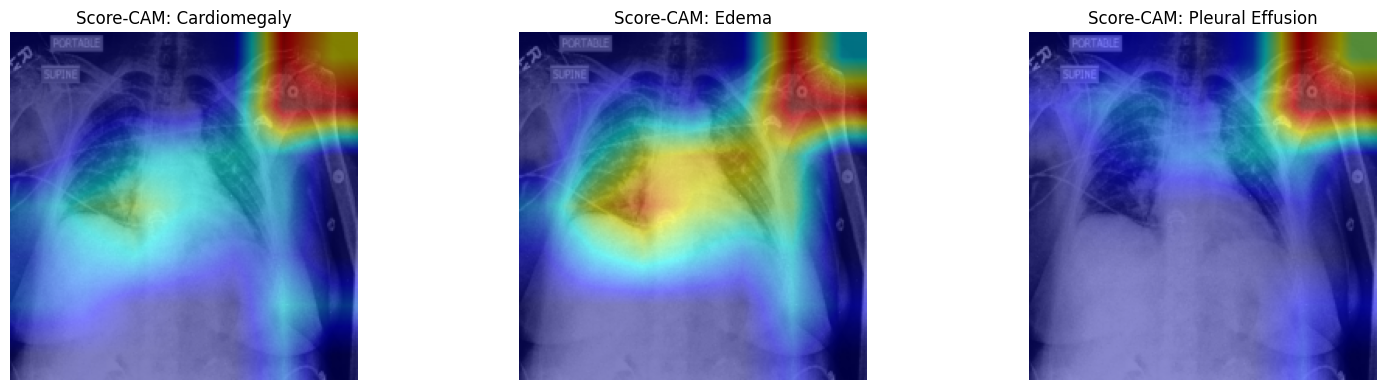

In [24]:
rgb_image=np.array(TF.resize(image,(224,224))).astype(np.float32)/255.0

plt.figure(figsize=(16,4))

for i,disease in enumerate(disease_cols):
    cam_image=show_cam_on_image(
        rgb_image,
        cams[i],
        use_rgb=True
    )

    plt.subplot(1,3,i+1)
    plt.imshow(cam_image)
    plt.title(f"Score-CAM: {disease}")
    plt.axis("off")

plt.tight_layout()
plt.show()

100%|██████████| 64/64 [00:03<00:00, 18.15it/s]


Cardiomegaly min= 0.0 max= 0.9999999 mean= 0.44300056 std= 0.2380167
Edema min= 0.0 max= 0.9999999 mean= 0.4254871 std= 0.22758575
Pleural Effusion min= 0.0 max= 0.9999999 mean= 0.4512212 std= 0.23504212


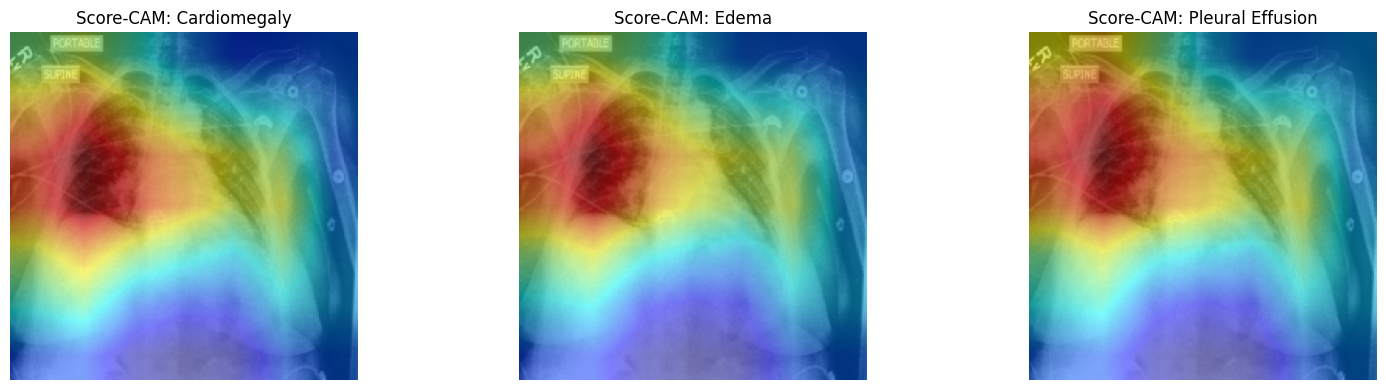

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Load Matched CNN
model_cnn_matched=CNNClassifier(
    num_classes=3,
    dropout=0.3
).to(device)

model_cnn_matched.load_state_dict(
    torch.load(
        os.path.join(model_dir,"best_cnn_matched.pth"),
        map_location=device
    )
)

model_cnn_matched.eval()

# Use the final spatial feature layer
target_layer_matched=model_cnn_matched.backbone.norm5

# Create Score-CAM
cam_matched=ScoreCAM(
    model=model_cnn_matched,
    target_layers=[target_layer_matched]
)

# Prepare image
rgb_image=np.array(
    TF.resize(image,(224,224))
).astype(np.float32)/255.0

# Generate one independent CAM per disease
cams_matched=[]

for i,disease in enumerate(disease_cols):
    grayscale_cam=cam_matched(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(i)]
    )[0]

    cams_matched.append(grayscale_cam)

# Print numerical sanity check
for i,disease in enumerate(disease_cols):
    print(
        disease,
        "min=",cams_matched[i].min(),
        "max=",cams_matched[i].max(),
        "mean=",cams_matched[i].mean(),
        "std=",cams_matched[i].std()
    )

# Plot
plt.figure(figsize=(16,4))

for i,disease in enumerate(disease_cols):
    cam_image=show_cam_on_image(
        rgb_image,
        cams_matched[i],
        use_rgb=True
    )

    plt.subplot(1,3,i+1)
    plt.imshow(cam_image)
    plt.title(f"Score-CAM: {disease}")
    plt.axis("off")

plt.tight_layout()
plt.show()

100%|██████████| 64/64 [00:04<00:00, 15.55it/s]


Cardiomegaly min= 0.0 max= 0.9999999 mean= 0.38307583 std= 0.23180279
Edema min= 0.0 max= 0.9999999 mean= 0.41949034 std= 0.24252993
Pleural Effusion min= 0.0 max= 0.9999999 mean= 0.35749805 std= 0.2631188


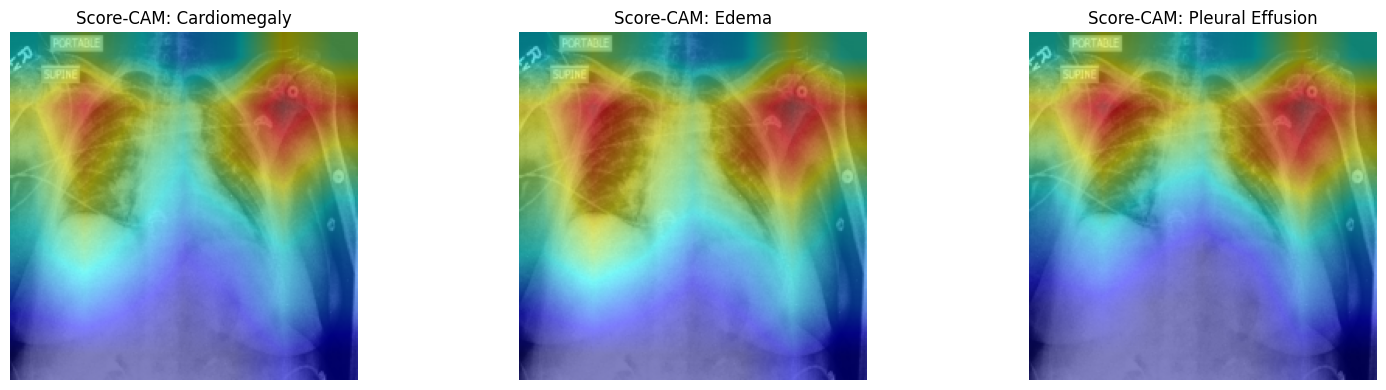

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Recreate Hybrid CNN-Transformer
class HybridCNNTransformer(nn.Module):
    def __init__(self,num_classes,dropout=0.3,num_transformer_layers=2,nhead=4):
        super().__init__()
        self.cnn_backbone=models.densenet121(weights="DEFAULT").features
        feature_dim=1024
        self.cls_token=nn.Parameter(torch.randn(1,1,feature_dim)*0.02)
        self.pos_embed=nn.Parameter(torch.randn(1,200,feature_dim)*0.02)

        encoder_layer=nn.TransformerEncoderLayer(
            d_model=feature_dim,
            nhead=nhead,
            dim_feedforward=feature_dim*2,
            dropout=dropout,
            batch_first=True
        )

        self.transformer=nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers
        )

        self.dropout=nn.Dropout(dropout)
        self.classifier=nn.Linear(feature_dim,num_classes)

    def forward(self,x):
        feat_map=F.relu(self.cnn_backbone(x))
        B,C,H,W=feat_map.shape

        tokens=feat_map.flatten(2).transpose(1,2)
        cls_tokens=self.cls_token.expand(B,-1,-1)
        tokens=torch.cat([cls_tokens,tokens],dim=1)
        tokens=tokens+self.pos_embed[:,:tokens.shape[1],:]

        out=self.transformer(tokens)

        return self.classifier(self.dropout(out[:,0,:]))


# Load trained Hybrid model
model_hybrid=HybridCNNTransformer(
    num_classes=3,
    dropout=0.3
).to(device)

model_hybrid.load_state_dict(
    torch.load(
        os.path.join(model_dir,"best_hybrid.pth"),
        map_location=device
    )
)

model_hybrid.eval()

# Use final DenseNet spatial feature layer
target_layer_hybrid=model_hybrid.cnn_backbone.norm5

# Score-CAM
cam_hybrid=ScoreCAM(
    model=model_hybrid,
    target_layers=[target_layer_hybrid]
)

# Prepare image
rgb_image=np.array(
    TF.resize(image,(224,224))
).astype(np.float32)/255.0

# Generate independent CAM for each disease
cams_hybrid=[]

for i,disease in enumerate(disease_cols):
    grayscale_cam=cam_hybrid(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(i)]
    )[0]

    cams_hybrid.append(grayscale_cam)

# Numerical sanity check
for i,disease in enumerate(disease_cols):
    print(
        disease,
        "min=",cams_hybrid[i].min(),
        "max=",cams_hybrid[i].max(),
        "mean=",cams_hybrid[i].mean(),
        "std=",cams_hybrid[i].std()
    )

# Plot
plt.figure(figsize=(16,4))

for i,disease in enumerate(disease_cols):
    cam_image=show_cam_on_image(
        rgb_image,
        cams_hybrid[i],
        use_rgb=True
    )

    plt.subplot(1,3,i+1)
    plt.imshow(cam_image)
    plt.title(f"Score-CAM: {disease}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
import os

for root,dirs,files in os.walk("/kaggle/input"):
    for file in files:
        if file=="train.csv":
            print(os.path.join(root,file))

/kaggle/input/datasets/ashery/chexpert/train.csv


KeyboardInterrupt: 

In [30]:
import pandas as pd

train_csv="/kaggle/input/datasets/ashery/chexpert/train.csv"

df=pd.read_csv(train_csv)

print("Shape:",df.shape)
print("Columns:")
print(df.columns.tolist())

Shape: (223414, 19)
Columns:
['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']


In [31]:
train_df=df.copy()

train_df=train_df[
    ["Path","Cardiomegaly","Edema","Pleural Effusion"]
].copy()

train_df=train_df.fillna(0)

# CheXpert uncertain labels: treat -1 as 0,
# matching the usual preprocessing used in your training pipeline
for disease in disease_cols:
    train_df[disease]=train_df[disease].replace(-1,0)

print(train_df[disease_cols].value_counts())

Cardiomegaly  Edema  Pleural Effusion
0.0           0.0    0.0                 102068
                     1.0                  53759
              1.0    1.0                  20592
                     0.0                  19995
1.0           0.0    0.0                   9434
              1.0    1.0                   5929
              0.0    1.0                   5907
              1.0    0.0                   5730
Name: count, dtype: int64


In [32]:
label_matrix=train_df[disease_cols].values.astype(np.float32)

co_occurrence=label_matrix.T@label_matrix

diag=np.diag(co_occurrence).copy()
diag[diag==0]=1.0

adjacency=co_occurrence/diag[:,None]
adjacency=(adjacency+adjacency.T)/2

adjacency_with_self_loops=adjacency+np.eye(3,dtype=np.float32)

degree=adjacency_with_self_loops.sum(axis=1)

D_inv_sqrt=np.diag(np.power(degree,-0.5))

adjacency_norm=torch.tensor(
    D_inv_sqrt@adjacency_with_self_loops@D_inv_sqrt,
    dtype=torch.float32
).to(device)

print("Adjacency:")
print(adjacency)

print("\nNormalized adjacency:")
print(adjacency_norm)

Adjacency:
[[1.         0.32748532 0.28784984]
 [0.32748532 1.         0.4076662 ]
 [0.28784984 0.4076662  1.        ]]

Normalized adjacency:
tensor([[0.7647, 0.1224, 0.1084],
        [0.1224, 0.7312, 0.1501],
        [0.1084, 0.1501, 0.7420]], device='cuda:0')


100%|██████████| 64/64 [00:03<00:00, 18.49it/s]


Cardiomegaly min= 0.0 max= 0.9999999 mean= 0.27079508 std= 0.2736273
Edema min= 0.0 max= 0.9999999 mean= 0.2987973 std= 0.2754658
Pleural Effusion min= 0.0 max= 0.9999999 mean= 0.19932702 std= 0.25856912


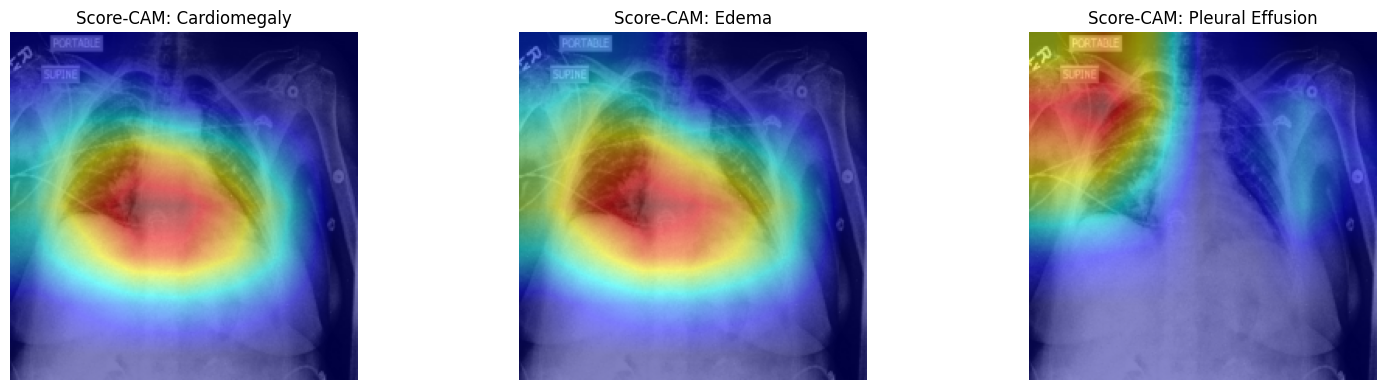

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class GraphConvolution(nn.Module):
    def __init__(self,in_f,out_f):
        super().__init__()
        self.weight=nn.Linear(in_f,out_f,bias=False)

    def forward(self,x,adj):
        return adj@self.weight(x)


class CheXGCN(nn.Module):
    def __init__(self,num_labels,feature_dim=1024,label_embed_dim=300,gcn_hidden=512,dropout=0.3):
        super().__init__()
        self.backbone=models.densenet121(weights="DEFAULT").features
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.dropout=nn.Dropout(dropout)
        self.label_embeddings=nn.Parameter(torch.randn(num_labels,label_embed_dim)*0.01)
        self.gcn1=GraphConvolution(label_embed_dim,gcn_hidden)
        self.gcn2=GraphConvolution(gcn_hidden,feature_dim)

    def forward(self,x,adj):
        feat=F.relu(self.backbone(x))
        feat=self.dropout(self.pool(feat).flatten(1))
        label_repr=F.relu(self.gcn1(self.label_embeddings,adj))
        label_repr=self.gcn2(label_repr,adj)
        return feat@label_repr.T


model_chexgcn=CheXGCN(num_labels=3).to(device)

model_chexgcn.load_state_dict(
    torch.load(
        os.path.join(model_dir,"best_chexgcn.pth"),
        map_location=device
    )
)

model_chexgcn.eval()


class CheXGCNCamWrapper(nn.Module):
    def __init__(self,model,adj):
        super().__init__()
        self.model=model
        self.adj=adj

    def forward(self,x):
        return self.model(x,self.adj)


chexgcn_cam_model=CheXGCNCamWrapper(
    model_chexgcn,
    adjacency_norm
).to(device)

chexgcn_cam_model.eval()

target_layer_chexgcn=model_chexgcn.backbone.norm5

cam_chexgcn=ScoreCAM(
    model=chexgcn_cam_model,
    target_layers=[target_layer_chexgcn]
)

rgb_image=np.array(
    TF.resize(image,(224,224))
).astype(np.float32)/255.0

cams_chexgcn=[]

for i,disease in enumerate(disease_cols):
    grayscale_cam=cam_chexgcn(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(i)]
    )[0]

    cams_chexgcn.append(grayscale_cam)

for i,disease in enumerate(disease_cols):
    print(
        disease,
        "min=",cams_chexgcn[i].min(),
        "max=",cams_chexgcn[i].max(),
        "mean=",cams_chexgcn[i].mean(),
        "std=",cams_chexgcn[i].std()
    )

plt.figure(figsize=(16,4))

for i,disease in enumerate(disease_cols):
    cam_image=show_cam_on_image(
        rgb_image,
        cams_chexgcn[i],
        use_rgb=True
    )

    plt.subplot(1,3,i+1)
    plt.imshow(cam_image)
    plt.title(f"Score-CAM: {disease}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
from itertools import combinations

all_cams={
    "CNN":cams,
    "Matched CNN":cams_matched,
    "Hybrid":cams_hybrid,
    "CheXGCN":cams_chexgcn
}

for model_name,model_cams in all_cams.items():
    print("\n",model_name)

    for i,j in combinations(range(3),2):
        a=model_cams[i].flatten()
        b=model_cams[j].flatten()

        correlation=torch.corrcoef(
            torch.stack([
                torch.tensor(a),
                torch.tensor(b)
            ])
        )[0,1].item()

        mean_diff=np.abs(a-b).mean()

        print(
            f"{disease_cols[i]} vs {disease_cols[j]}: "
            f"correlation={correlation:.4f}, "
            f"mean_diff={mean_diff:.4f}"
        )


 CNN
Cardiomegaly vs Edema: correlation=0.8974, mean_diff=0.0896
Cardiomegaly vs Pleural Effusion: correlation=0.7898, mean_diff=0.1166
Edema vs Pleural Effusion: correlation=0.6604, mean_diff=0.1523

 Matched CNN
Cardiomegaly vs Edema: correlation=0.9840, mean_diff=0.0354
Cardiomegaly vs Pleural Effusion: correlation=0.9722, mean_diff=0.0460
Edema vs Pleural Effusion: correlation=0.9926, mean_diff=0.0282

 Hybrid
Cardiomegaly vs Edema: correlation=0.9863, mean_diff=0.0436
Cardiomegaly vs Pleural Effusion: correlation=0.9710, mean_diff=0.0577
Edema vs Pleural Effusion: correlation=0.9529, mean_diff=0.0740

 CheXGCN
Cardiomegaly vs Edema: correlation=0.9761, mean_diff=0.0415
Cardiomegaly vs Pleural Effusion: correlation=0.1512, mean_diff=0.2508
Edema vs Pleural Effusion: correlation=0.3596, mean_diff=0.2248


In [35]:
import numpy as np

# Conservative central thorax region
h,w=cams[0].shape

yy,xx=np.ogrid[:h,:w]

cx=w/2
cy=h*0.55

rx=w*0.42
ry=h*0.42

thorax_mask=((xx-cx)/rx)**2+((yy-cy)/ry)**2<=1

all_cams={
    "CNN":cams,
    "Matched CNN":cams_matched,
    "Hybrid":cams_hybrid,
    "CheXGCN":cams_chexgcn
}

for model_name,model_cams in all_cams.items():
    print("\n",model_name)

    for i,disease in enumerate(disease_cols):
        cam_map=model_cams[i]

        inside=cam_map[thorax_mask].mean()
        outside=cam_map[~thorax_mask].mean()

        total=cam_map.mean()

        inside_ratio=inside/(total+1e-8)

        print(
            f"{disease}: "
            f"inside={inside:.4f}, "
            f"outside={outside:.4f}, "
            f"inside/total={inside_ratio:.3f}"
        )


 CNN
Cardiomegaly: inside=0.2239, outside=0.1984, inside/total=1.053
Edema: inside=0.3327, outside=0.1768, inside/total=1.264
Pleural Effusion: inside=0.0945, outside=0.1935, inside/total=0.681

 Matched CNN
Cardiomegaly: inside=0.5010, outside=0.3709, inside/total=1.131
Edema: inside=0.4641, outside=0.3775, inside/total=1.091
Pleural Effusion: inside=0.4831, outside=0.4116, inside/total=1.071

 Hybrid
Cardiomegaly: inside=0.3777, outside=0.3897, inside/total=0.986
Edema: inside=0.4390, outside=0.3952, inside/total=1.047
Pleural Effusion: inside=0.3396, outside=0.3798, inside/total=0.950

 CheXGCN
Cardiomegaly: inside=0.4240, outside=0.0804, inside/total=1.566
Edema: inside=0.4353, outside=0.1291, inside/total=1.457
Pleural Effusion: inside=0.1650, outside=0.2420, inside/total=0.828


In [36]:
for model_name,model_cams in all_cams.items():
    print("\n",model_name)

    for i,disease in enumerate(disease_cols):
        cam_map=model_cams[i]

        total_mass=cam_map.sum()
        inside_mass=cam_map[thorax_mask].sum()
        outside_mass=cam_map[~thorax_mask].sum()

        inside_ratio=inside_mass/(total_mass+1e-8)
        outside_ratio=outside_mass/(total_mass+1e-8)

        print(
            f"{disease}: "
            f"inside_mass={inside_ratio:.3f}, "
            f"outside_mass={outside_ratio:.3f}"
        )


 CNN
Cardiomegaly: inside_mass=0.584, outside_mass=0.416
Edema: inside_mass=0.700, outside_mass=0.300
Pleural Effusion: inside_mass=0.378, outside_mass=0.622

 Matched CNN
Cardiomegaly: inside_mass=0.627, outside_mass=0.373
Edema: inside_mass=0.604, outside_mass=0.396
Pleural Effusion: inside_mass=0.593, outside_mass=0.407

 Hybrid
Cardiomegaly: inside_mass=0.546, outside_mass=0.454
Edema: inside_mass=0.580, outside_mass=0.420
Pleural Effusion: inside_mass=0.526, outside_mass=0.474

 CheXGCN
Cardiomegaly: inside_mass=0.868, outside_mass=0.132
Edema: inside_mass=0.807, outside_mass=0.193
Pleural Effusion: inside_mass=0.459, outside_mass=0.541


In [37]:
import glob
import numpy as np
import pandas as pd
from PIL import Image
from torchvision.transforms import functional as TF
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# --------------------------------------------------
# 1. Get 10 frontal validation X-rays
# --------------------------------------------------

valid_paths=glob.glob(
    "/kaggle/input/datasets/ashery/chexpert/valid/**/view1_frontal.jpg",
    recursive=True
)

valid_paths=valid_paths[:10]

print("Images:",len(valid_paths))


# --------------------------------------------------
# 2. Thorax proxy mask
# --------------------------------------------------

h=w=224

yy,xx=np.ogrid[:h,:w]

cx=w/2
cy=h*0.55
rx=w*0.42
ry=h*0.42

thorax_mask=((xx-cx)/rx)**2+((yy-cy)/ry)**2<=1


# --------------------------------------------------
# 3. CAM objects
# --------------------------------------------------

cam_objects={
    "CNN":ScoreCAM(
        model=model_cnn,
        target_layers=[model_cnn.backbone.norm5]
    ),

    "Matched CNN":ScoreCAM(
        model=model_cnn_matched,
        target_layers=[model_cnn_matched.backbone.norm5]
    ),

    "Hybrid":ScoreCAM(
        model=model_hybrid,
        target_layers=[model_hybrid.cnn_backbone.norm5]
    ),

    "CheXGCN":ScoreCAM(
        model=chexgcn_cam_model,
        target_layers=[model_chexgcn.backbone.norm5]
    )
}


# --------------------------------------------------
# 4. Generate CAMs
# --------------------------------------------------

results=[]

for image_idx,image_path in enumerate(valid_paths):

    print(f"\nImage {image_idx+1}/{len(valid_paths)}")

    img=Image.open(image_path).convert("RGB")

    input_img=TF.resize(img,(224,224))
    input_tensor_i=TF.to_tensor(input_img).unsqueeze(0).to(device)

    for model_name,cam_object in cam_objects.items():

        for disease_idx,disease in enumerate(disease_cols):

            grayscale_cam=cam_object(
                input_tensor=input_tensor_i,
                targets=[ClassifierOutputTarget(disease_idx)]
            )[0]

            total_mass=grayscale_cam.sum()
            inside_mass=grayscale_cam[thorax_mask].sum()

            inside_ratio=inside_mass/(total_mass+1e-8)

            results.append({
                "image":image_idx+1,
                "model":model_name,
                "disease":disease,
                "inside_mass":inside_ratio,
                "outside_mass":1-inside_ratio
            })


# --------------------------------------------------
# 5. Aggregate results
# --------------------------------------------------

results_df=pd.DataFrame(results)

summary=(
    results_df
    .groupby(["model","disease"])[["inside_mass","outside_mass"]]
    .mean()
    .reset_index()
)

print("\n===== AVERAGE CAM MASS =====")
print(summary.to_string(index=False))

Images: 10

Image 1/10


100%|██████████| 64/64 [00:03<00:00, 17.45it/s]



Image 2/10


100%|██████████| 64/64 [00:03<00:00, 17.95it/s]



Image 3/10


...


Image 9/10


100%|██████████| 64/64 [00:03<00:00, 17.74it/s]



Image 10/10


100%|██████████| 64/64 [00:03<00:00, 17.76it/s]


===== AVERAGE CAM MASS =====
      model          disease  inside_mass  outside_mass
        CNN     Cardiomegaly     0.374575      0.625425
        CNN            Edema     0.441248      0.558752
        CNN Pleural Effusion     0.428720      0.571280
    CheXGCN     Cardiomegaly     0.757174      0.242826
    CheXGCN            Edema     0.724061      0.275939
    CheXGCN Pleural Effusion     0.648409      0.351591
     Hybrid     Cardiomegaly     0.593786      0.406214
     Hybrid            Edema     0.611574      0.388426
     Hybrid Pleural Effusion     0.593474      0.406526
Matched CNN     Cardiomegaly     0.579957      0.420043
Matched CNN            Edema     0.573487      0.426513
Matched CNN Pleural Effusion     0.564601      0.435399


In [1]:
import glob
import numpy as np
import pandas as pd
from PIL import Image
from torchvision.transforms import functional as TF
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# --------------------------------------------------
# 1. Get 100 frontal validation X-rays
# --------------------------------------------------

valid_paths=glob.glob(
    "/kaggle/input/datasets/ashery/chexpert/valid/**/view1_frontal.jpg",
    recursive=True
)

valid_paths=valid_paths[:100]

print("Images:",len(valid_paths))


# --------------------------------------------------
# 2. Thorax proxy mask
# --------------------------------------------------

h=w=224

yy,xx=np.ogrid[:h,:w]

cx=w/2
cy=h*0.55
rx=w*0.42
ry=h*0.42

thorax_mask=((xx-cx)/rx)**2+((yy-cy)/ry)**2<=1


# --------------------------------------------------
# 3. Create Score-CAM objects
# --------------------------------------------------

cam_objects={
    "CNN":ScoreCAM(
        model=model_cnn,
        target_layers=[model_cnn.backbone.norm5]
    ),

    "Matched CNN":ScoreCAM(
        model=model_cnn_matched,
        target_layers=[model_cnn_matched.backbone.norm5]
    ),

    "Hybrid":ScoreCAM(
        model=model_hybrid,
        target_layers=[model_hybrid.cnn_backbone.norm5]
    ),

    "CheXGCN":ScoreCAM(
        model=chexgcn_cam_model,
        target_layers=[model_chexgcn.backbone.norm5]
    )
}


# --------------------------------------------------
# 4. Run Score-CAM
# --------------------------------------------------

results=[]

for image_idx,image_path in enumerate(valid_paths):

    if (image_idx+1)%10==0:
        print(f"Processed {image_idx+1}/{len(valid_paths)}")

    img=Image.open(image_path).convert("RGB")

    input_img=TF.resize(img,(224,224))
    input_tensor_i=TF.to_tensor(input_img).unsqueeze(0).to(device)

    for model_name,cam_object in cam_objects.items():

        for disease_idx,disease in enumerate(disease_cols):

            grayscale_cam=cam_object(
                input_tensor=input_tensor_i,
                targets=[ClassifierOutputTarget(disease_idx)]
            )[0]

            total_mass=grayscale_cam.sum()
            inside_mass=grayscale_cam[thorax_mask].sum()

            inside_ratio=inside_mass/(total_mass+1e-8)

            results.append({
                "image":image_idx+1,
                "model":model_name,
                "disease":disease,
                "inside_mass":inside_ratio
            })


# --------------------------------------------------
# 5. Mean ± standard deviation
# --------------------------------------------------

results_df=pd.DataFrame(results)

summary=(
    results_df
    .groupby(["model","disease"])["inside_mass"]
    .agg(["mean","std"])
    .reset_index()
)

summary["result"]=summary.apply(
    lambda row:f"{row['mean']:.3f} ± {row['std']:.3f}",
    axis=1
)

print("\n===== CAM MASS INSIDE THORAX: 100 IMAGES =====")
print(
    summary[
        ["model","disease","result"]
    ].to_string(index=False)
)

Images: 100


NameError: name 'model_cnn' is not defined